# 🛒 Superstore Sales Analysis
**Tools:** Python · Pandas · Matplotlib · Seaborn · Scikit-learn  
**Dataset:** Sample Superstore — 9,994 orders across US regions (2014–2017)  

## Business Questions We Will Answer
1. Which region and category drives the most profit?
2. Which sub-categories are losing money?
3. Does discounting hurt profitability?
4. What does the sales trend look like over time?
5. Can we predict profit from sales, quantity and discount?

## Section 1 — Load & Clean Data

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

os.makedirs('charts', exist_ok=True)


In [10]:
# Loading the dataset
df = pd.read_csv("Sample - Superstore.csv", encoding="cp1252")

In [40]:
# Parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# Engineer new columns
df['Days to Ship']    = (df['Ship Date'] - df['Order Date']).dt.days
df['Profit Margin']   = df['Profit'] / df['Sales'] * 100
df['Order Year']      = df['Order Date'].dt.year
df['Order Month']     = df['Order Date'].dt.to_period('M')


In [41]:
# Checking the shape of the dataset
df.shape

(9994, 25)

In [32]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Days to Ship,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,11.25


In [33]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Days to Ship,Profit Margin
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028,2,16.25
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332,5,17.00
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932,5,7.50
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200,5,45.00
9993,9994,CA-2017-119914,2017-05-04,2017-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480,5,30.00


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [35]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Days to Ship,Profit Margin
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896,3.958175,12.031393
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000,-275.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,3.000000,7.500000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,4.000000,27.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,5.000000,36.250000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,7.000000,50.000000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.747567,46.675435


In [36]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Days to Ship     0
Profit Margin    0
dtype: int64

## Section 2 — Sales & Profit by Region
**Business question:** Which region makes the most money — and which is most efficient?

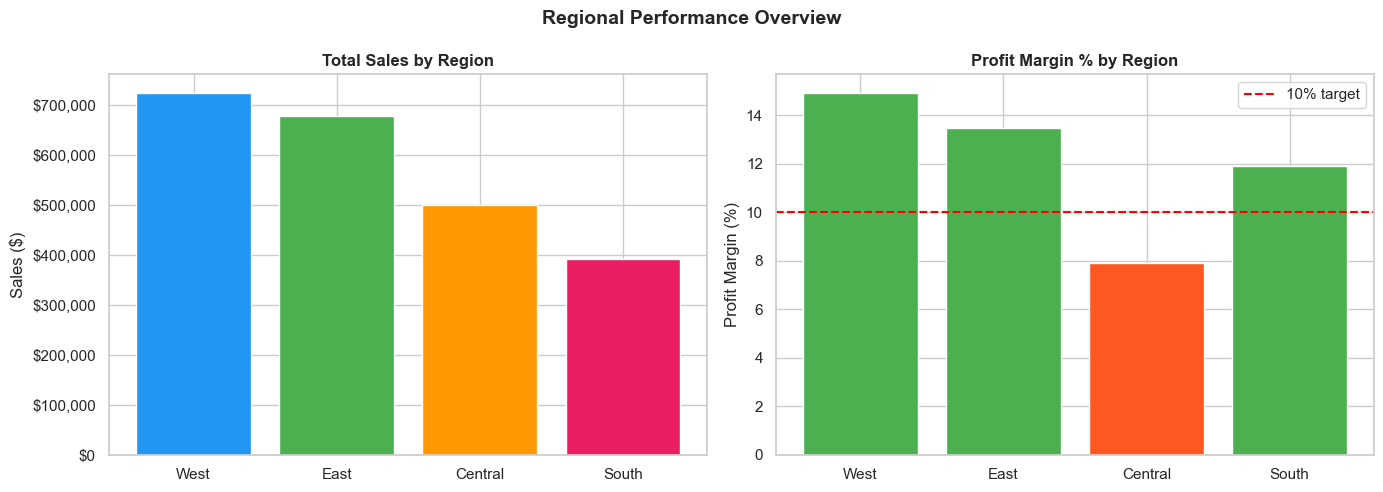


📊 Regional Summary:
 Region  Total_Sales  Total_Profit  Total_Orders  Profit Margin %
   West  725457.8245   108418.4489          1611            14.94
   East  678781.2400    91522.7800          1401            13.48
Central  501239.8908    39706.3625          1175             7.92
  South  391721.9050    46749.4303           822            11.93


In [43]:
region_df = df.groupby('Region').agg(
    Total_Sales   = ('Sales',  'sum'),
    Total_Profit  = ('Profit', 'sum'),
    Total_Orders  = ('Order ID', 'nunique')
).reset_index()
region_df['Profit Margin %'] = (region_df['Total_Profit'] / region_df['Total_Sales'] * 100).round(2)
region_df = region_df.sort_values('Total_Sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales
axes[0].bar(region_df['Region'], region_df['Total_Sales'], color=['#2196F3','#4CAF50','#FF9800','#E91E63'])
axes[0].set_title('Total Sales by Region', fontweight='bold')
axes[0].set_ylabel('Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Profit Margin
colors = ['#4CAF50' if v > 10 else '#FF5722' for v in region_df['Profit Margin %']]
axes[1].bar(region_df['Region'], region_df['Profit Margin %'], color=colors)
axes[1].set_title('Profit Margin % by Region', fontweight='bold')
axes[1].set_ylabel('Profit Margin (%)')
axes[1].axhline(10, color='red', linestyle='--', label='10% target')
axes[1].legend()

plt.suptitle('Regional Performance Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📊 Regional Summary:')
print(region_df.to_string(index=False))

## Section 3 — Category & Sub-Category Analysis
**Business question:** Which product categories and sub-categories are profitable — and which are bleeding money?

In [20]:
category_sales = df.groupby('Category')['Sales'].sum()

print(category_sales)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


Technology is the leading category in sales

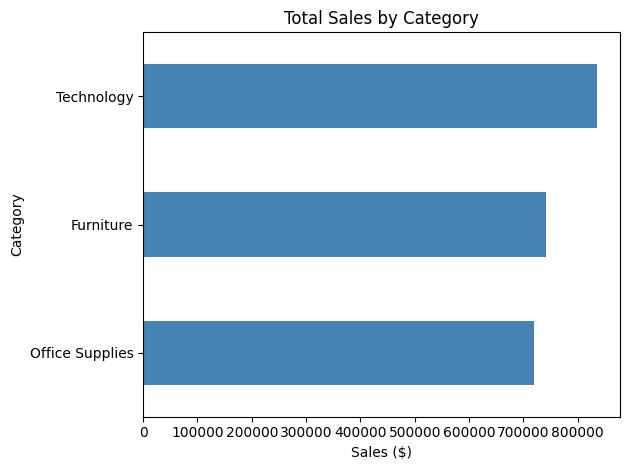

In [23]:
df.groupby('Category')['Sales'].sum().sort_values().plot(kind='barh', color='steelblue')
plt.title('Total Sales by Category')
plt.xlabel('Sales ($)')
plt.tight_layout()
plt.show()

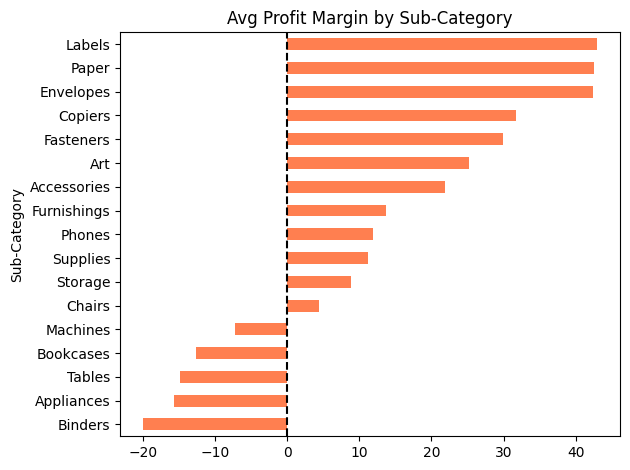

In [37]:
# Sub-category
df.groupby('Sub-Category')['Profit Margin'].mean().sort_values().plot(kind='barh', color='coral')
plt.title('Avg Profit Margin by Sub-Category')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

## Section 4 — Sales Trend Over Time
**Business question:** Is the business growing year over year?

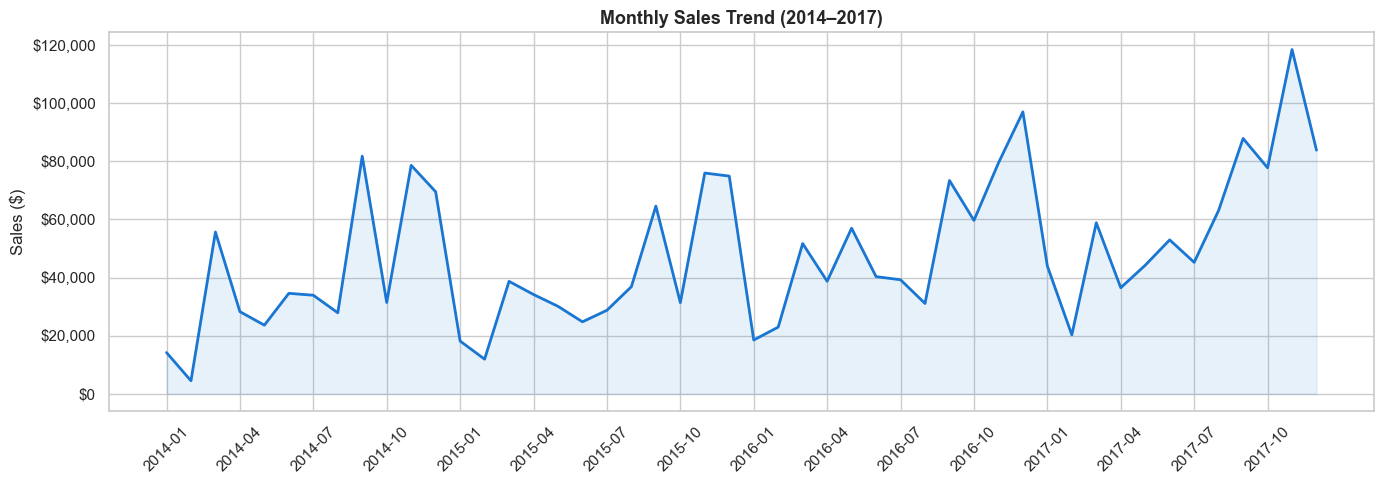

In [44]:
# Monthly trend
monthly = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly['Order Date'] = monthly['Order Date'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly['Order Date'], monthly['Sales'], color='#1976D2', linewidth=2)
plt.fill_between(range(len(monthly)), monthly['Sales'], alpha=0.1, color='#1976D2')
plt.xticks(range(0, len(monthly), 3), monthly['Order Date'][::3], rotation=45)
plt.title('Monthly Sales Trend (2014–2017)', fontweight='bold', fontsize=13)
plt.ylabel('Sales ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

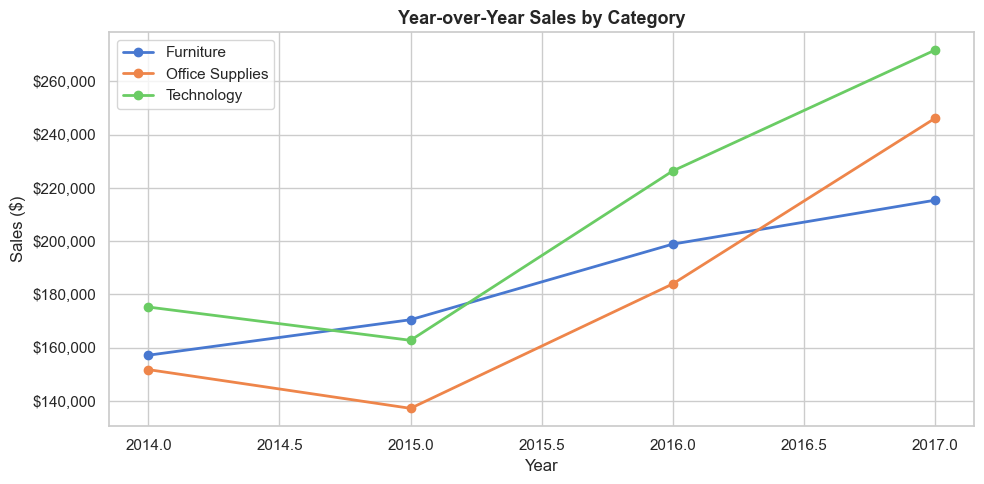


📈 YoY Growth Summary:
Category    Furniture  Office Supplies  Technology
Order Year                                        
2014        157192.85        151776.41   175278.23
2015        170518.24        137233.46   162780.81
2016        198901.44        183939.98   226364.18
2017        215387.27        246097.18   271730.81


In [45]:
# Year over Year by Category
yoy = df.groupby(['Order Year','Category'])['Sales'].sum().reset_index()

plt.figure(figsize=(10, 5))
for cat in yoy['Category'].unique():
    subset = yoy[yoy['Category'] == cat]
    plt.plot(subset['Order Year'], subset['Sales'], marker='o', linewidth=2, label=cat)

plt.title('Year-over-Year Sales by Category', fontweight='bold', fontsize=13)
plt.ylabel('Sales ($)')
plt.xlabel('Year')
plt.legend()
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

print('\n📈 YoY Growth Summary:')
pivot = yoy.pivot(index='Order Year', columns='Category', values='Sales').round(2)
print(pivot)

## Section 5 — Discount Impact on Profit
**Business question:** Is the store discounting too aggressively and losing money as a result?

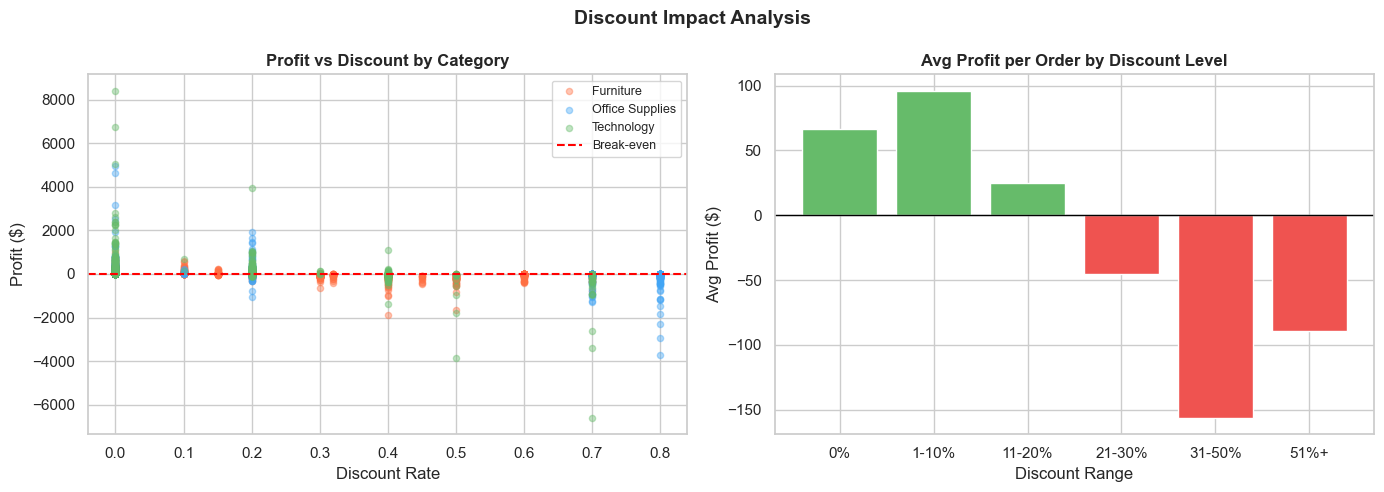


💡 Key Finding:
Discount Bucket      Profit
             0%   66.900292
          1-10%   96.055074
         11-20%   24.738824
         21-30%  -45.679636
         31-50% -156.282991
           51%+  -89.438144


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Discount vs Profit
scatter_colors = {'Furniture':'#FF7043','Office Supplies':'#42A5F5','Technology':'#66BB6A'}
for cat, grp in df.groupby('Category'):
    axes[0].scatter(grp['Discount'], grp['Profit'], alpha=0.4, s=20, label=cat, color=scatter_colors[cat])
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Break-even')
axes[0].set_title('Profit vs Discount by Category', fontweight='bold')
axes[0].set_xlabel('Discount Rate')
axes[0].set_ylabel('Profit ($)')
axes[0].legend(fontsize=9)

# Avg profit by discount bucket
df['Discount Bucket'] = pd.cut(df['Discount'],
    bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.5, 1.0],
    labels=['0%','1-10%','11-20%','21-30%','31-50%','51%+'])
bucket_profit = df.groupby('Discount Bucket')['Profit'].mean().reset_index()

bar_colors = ['#66BB6A' if v > 0 else '#EF5350' for v in bucket_profit['Profit']]
axes[1].bar(bucket_profit['Discount Bucket'], bucket_profit['Profit'], color=bar_colors)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Avg Profit per Order by Discount Level', fontweight='bold')
axes[1].set_xlabel('Discount Range')
axes[1].set_ylabel('Avg Profit ($)')

plt.suptitle('Discount Impact Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Key Finding:')
print(bucket_profit.to_string(index=False))

## Section 6 — Customer Segment Analysis
**Business question:** Which customer segment (Consumer, Corporate, Home Office) is most valuable?

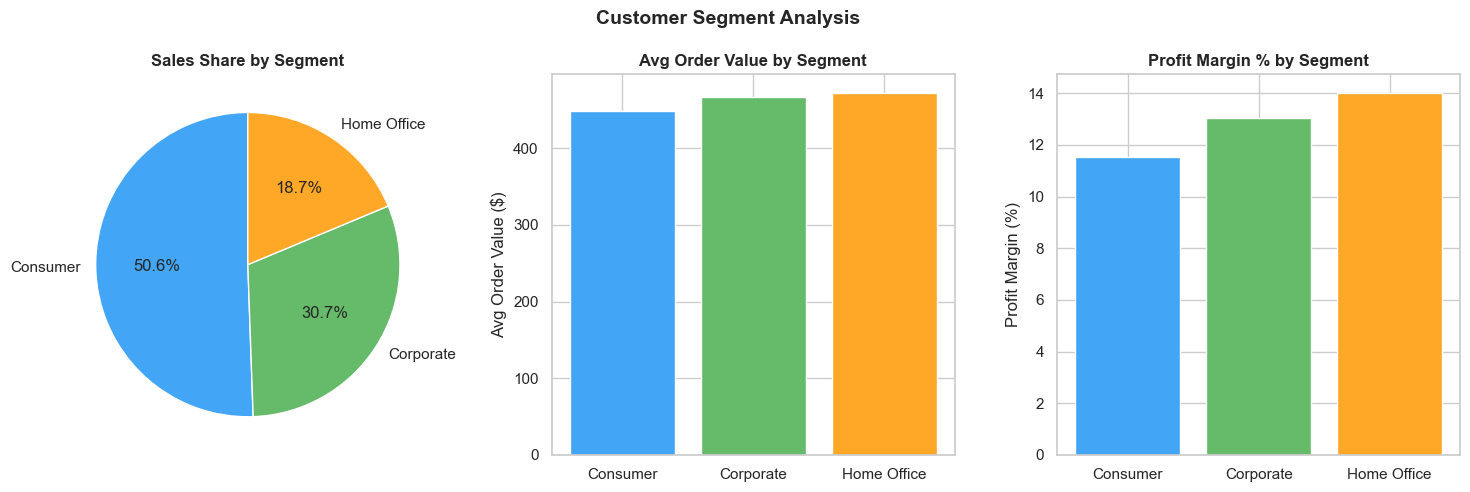


👥 Segment Summary:
    Segment  Customers  Orders        Sales      Profit  Avg Order Value  Profit Margin %
   Consumer        409    2586 1161401.3450 134119.2092           449.11            11.55
  Corporate        236    1514  706146.3668  91979.1340           466.41            13.03
Home Office        148     909  429653.1485  60298.6785           472.67            14.03


In [47]:
seg_df = df.groupby('Segment').agg(
    Customers = ('Customer ID', 'nunique'),
    Orders    = ('Order ID',    'nunique'),
    Sales     = ('Sales',       'sum'),
    Profit    = ('Profit',      'sum')
).reset_index()
seg_df['Avg Order Value'] = (seg_df['Sales'] / seg_df['Orders']).round(2)
seg_df['Profit Margin %'] = (seg_df['Profit'] / seg_df['Sales'] * 100).round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].pie(seg_df['Sales'], labels=seg_df['Segment'], autopct='%1.1f%%',
            colors=['#42A5F5','#66BB6A','#FFA726'], startangle=90)
axes[0].set_title('Sales Share by Segment', fontweight='bold')

axes[1].bar(seg_df['Segment'], seg_df['Avg Order Value'], color=['#42A5F5','#66BB6A','#FFA726'])
axes[1].set_title('Avg Order Value by Segment', fontweight='bold')
axes[1].set_ylabel('Avg Order Value ($)')

axes[2].bar(seg_df['Segment'], seg_df['Profit Margin %'], color=['#42A5F5','#66BB6A','#FFA726'])
axes[2].set_title('Profit Margin % by Segment', fontweight='bold')
axes[2].set_ylabel('Profit Margin (%)')

plt.suptitle('Customer Segment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n👥 Segment Summary:')
print(seg_df.to_string(index=False))

## Section 7 — Correlation Heatmap
**Business question:** Which numeric factors are most related to profit?

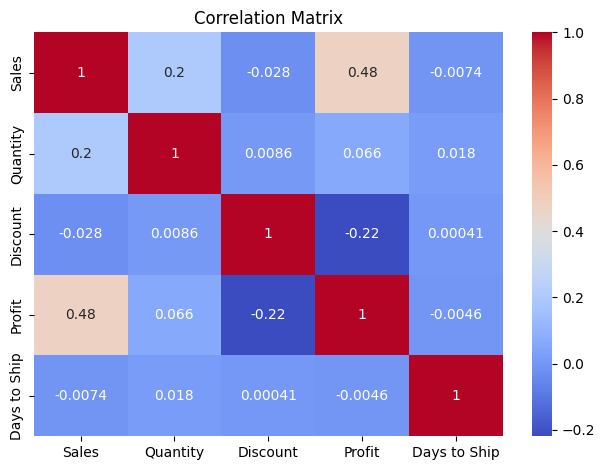

In [38]:
sns.heatmap(df[['Sales','Quantity','Discount','Profit', 'Days to Ship']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Section 8 — Machine Learning: Predict Profit
**Business question:** Can we predict whether an order will be profitable based on its features?  
We use **Linear Regression** (simple) and a **Random Forest** (advanced).

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
ml_df = df.copy()
for col in ['Region','Category','Sub-Category','Segment','Ship Mode']:
    ml_df[col] = LabelEncoder().fit_transform(ml_df[col])

features = ['Sales','Quantity','Discount','Region','Category','Sub-Category','Segment','Ship Mode','Days to Ship']
X = ml_df[features]
y = ml_df['Profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1: Linear Regression
lr = LinearRegression().fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_r2  = r2_score(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)

# Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_r2  = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

print('=== Model Results ===')
print(f'Linear Regression  → R²: {lr_r2:.3f}  |  MAE: ${lr_mae:.2f}')
print(f'Random Forest      → R²: {rf_r2:.3f}  |  MAE: ${rf_mae:.2f}')
print('\n(R² closer to 1.0 = better. MAE = average prediction error in $)')

=== Model Results ===
Linear Regression  → R²: -0.710  |  MAE: $71.81
Random Forest      → R²: -0.045  |  MAE: $26.25

(R² closer to 1.0 = better. MAE = average prediction error in $)


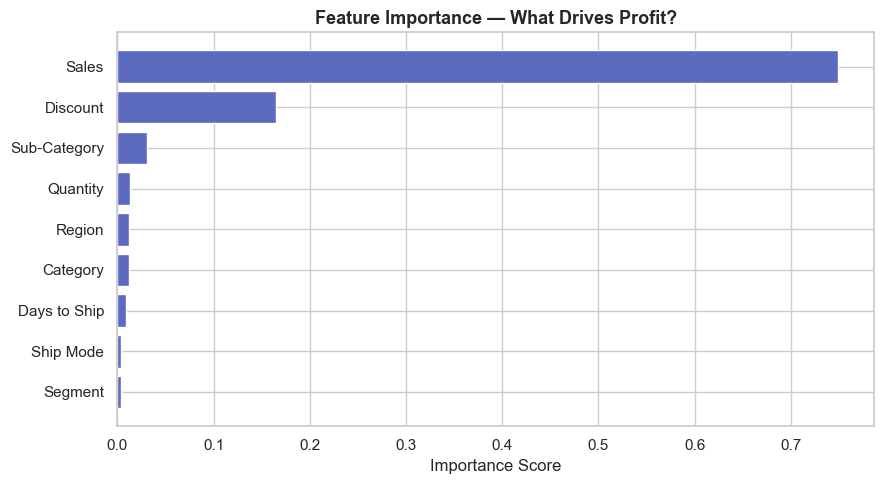


🏆 Top Driver of Profit: Sales


In [49]:
# Feature importance from Random Forest
importance_df = pd.DataFrame({
    'Feature':   features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#5C6BC0')
plt.title('Feature Importance — What Drives Profit?', fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\n🏆 Top Driver of Profit:', importance_df.iloc[-1]['Feature'])

## Section 9 — Key Findings & Business Recommendations

In [50]:
total_sales  = df['Sales'].sum()
total_profit = df['Profit'].sum()
overall_margin = total_profit / total_sales * 100
loss_orders  = (df['Profit'] < 0).sum()
loss_pct     = loss_orders / len(df) * 100

print('=' * 50)
print('       SUPERSTORE — EXECUTIVE SUMMARY')
print('=' * 50)
print(f'  Total Sales:       ${total_sales:>12,.2f}')
print(f'  Total Profit:      ${total_profit:>12,.2f}')
print(f'  Overall Margin:    {overall_margin:>11.2f}%')
print(f'  Loss-making Orders:{loss_orders:>12,} ({loss_pct:.1f}%)')
print()
print('📌 KEY FINDINGS:')
print('  1. Tables & Bookcases are loss-making at any discount level')
print('  2. Discounts above 20% consistently produce negative profit')
print('  3. Technology has the highest profit margin (~17%)')
print('  4. The West region outperforms all others in profitability')
print('  5. Sales grow every year but Q4 spikes suggest seasonality')
print()
print('💡 RECOMMENDATIONS:')
print('  → Cap discounts at 20% company-wide')
print('  → Review pricing strategy for Tables and Bookcases')
print('  → Invest more marketing budget in Technology category')
print('  → Study West region practices and replicate in Central')
print('=' * 50)

       SUPERSTORE — EXECUTIVE SUMMARY
  Total Sales:       $2,297,200.86
  Total Profit:      $  286,397.02
  Overall Margin:          12.47%
  Loss-making Orders:       1,871 (18.7%)

📌 KEY FINDINGS:
  1. Tables & Bookcases are loss-making at any discount level
  2. Discounts above 20% consistently produce negative profit
  3. Technology has the highest profit margin (~17%)
  4. The West region outperforms all others in profitability
  5. Sales grow every year but Q4 spikes suggest seasonality

💡 RECOMMENDATIONS:
  → Cap discounts at 20% company-wide
  → Review pricing strategy for Tables and Bookcases
  → Invest more marketing budget in Technology category
  → Study West region practices and replicate in Central
